# Setup

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# Read Data

In [2]:
folder_path = '../data/extracted_signals/'
data = []
file_name = []
for filename in glob.glob(os.path.join(folder_path, '*.npy')):
    with open(filename, 'r') as f:
        data.append(np.load(filename))
        file_name.append(filename)
#data = np.load("../data/extracted_signals/220516_No contraction videos.npy")
print(f'Nr of files: {len(data)}')

Nr of files: 15


In [3]:
idx_weak = []
idx_strong = []
idx_no= []
for n, file in enumerate(file_name):
    if "Weak" in file:
        print("weak", file)
        idx_weak.append(n)
    elif "Strong" in file:
        print("strong", file)
        idx_strong.append(n)
    else:
        print("no", file)
        idx_no.append(n)

weak ../data/extracted_signals/Weak contraction.lif - O1443_1b.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1319_3a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1445_2a.npy
weak ../data/extracted_signals/Weak contraction.lif - O1318_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1466_2a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1463_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1468_1b.npy
strong ../data/extracted_signals/Strong contraction.lif - O1319_1a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1450_2 curare II.npy
weak ../data/extracted_signals/Weak contraction.lif - O1318_2a.npy
no ../data/extracted_signals/220516_No contraction videos.lif - O1498_1a curare.npy
strong ../data/extracted_signals/Strong contraction.lif - O1464_2a.npy
weak ../data/extracted_signals/Weak contraction.lif - O1301_3a.npy
strong ../data/extracted_signals/Strong contrac

In [4]:
data_weak = [data[i] for i in idx_weak]
data_strong = [data[i] for i in idx_strong]
data_no = [data[i] for i in idx_no]

# Process Time Series
* One time series per video

In [108]:
def process_single_ts(data, norm=True, detrend=True, degree=6, diff=True, smooth=True, smooth_n=20, p=75):
    statistics = {}  
        
    # detrend data
    trend = np.zeros(data.shape)
    if detrend:
        for i in range(data.shape[0]):
            x = np.linspace(0, data[0,:].shape[0], data[0,:].shape[0])
            y = data[i,:]
            model = np.polyfit(x, y, degree)
            trend[i,:] = np.polyval(model, x)
            
    data = data - trend
    statistics['detrend'] = {}
    statistics['detrend']['mean'] = np.mean(data,axis=1)
    statistics['detrend']['std'] = np.std(data,axis=1)
    statistics['detrend']['per'] = np.percentile(data, p, axis=1)
          
        
    # calculate first difference
    if diff:
        data_diff = np.zeros((data.shape[0], data.shape[1]-1))
        for i in range(data.shape[0]):
            data_diff[i,:] = np.diff(data[i,:])
            result = adfuller(data_diff[i,:], autolag='AIC')
            print(f'ADF Statistic: {result[0]}')
            print(f'p-value: {result[1]}')
            #for key, value in result[4].items():
            #    print('Critial Values:')
            #    print(f'   {key}, {value}')
    else:
        data_diff = data
    
    if smooth:
        n=smooth_n
        data_smooth = np.zeros((data_diff.shape[0], data_diff.shape[1]-(n-1)))
        for i in range(data_diff.shape[0]):
            data_smooth[i,:] = np.convolve(data_diff[i,:], np.ones(n)/n, mode='valid')
    else:
        data_smooth = data_diff
    
    if norm:
        # normalize time series
        mean = np.mean(data_smooth,axis=1).reshape(-1,1)
        std = np.std(data_smooth,axis=1).reshape(-1,1)
        data_smooth = (data_smooth-mean)/std
        
    # mean over time series
    data_detrend_mean = np.mean(data_smooth, axis=0)
    statistics['detrend_mean'] = {}
    statistics['detrend_mean']['mean'] = np.mean(data_detrend_mean)
    statistics['detrend_mean']['std'] = np.std(data_detrend_mean)
    statistics['detrend_mean']['per'] = np.percentile(data_detrend_mean, p)
    
    # window function for fft
    hann_s = np.hanning(data_smooth.shape[1])
    # multiply window function with time series
    signal_hann = data_detrend_mean*hann_s
    # fft
    N = int(data_smooth.shape[1]/2) + 1
    y_hann = np.zeros(signal_hann.shape)
    #y_hann_plot = np.zeros(signal_hann[i,:N].shape)
    y_hann = np.fft.fft(signal_hann)
    #y_hann_plot[i,:]= 2.0*np.abs(y_hann[i,:N])/N
    
    # convert to period
    fa = 1
    X = np.linspace(0, fa/2, N, endpoint=True)
    Xp = 1.0/X 

    return data_detrend_mean, data_smooth, y_hann, X, Xp, statistics #y_hann_plot

In [121]:
data_weak_detrend_mean = []
data_weak_smooth_mean = []
y_hann_weak_mean = []
X_weak_mean = []
Xp_weak_mean = []
statistics_weak_mean = []
    
for j, data in enumerate(data_weak):
    data_detrend_mean, data_smooth, y_hann, X, Xp, statistics = process_single_ts(data, norm=True, detrend=True, degree=6, diff=True, smooth=True, smooth_n=50, p=95)
    
    data_weak_detrend_mean.append(data_detrend_mean)
    data_weak_smooth_mean.append(data_smooth)
    y_hann_weak_mean.append(y_hann)
    X_weak_mean.append(X)
    Xp_weak_mean.append(Xp)
    statistics_weak_mean.append(statistics)

ADF Statistic: -13.494909173080119
p-value: 3.055224996448398e-25
ADF Statistic: -13.316014502358128
p-value: 6.600943081625997e-25
ADF Statistic: -13.946309476287245
p-value: 4.790353507298743e-26
ADF Statistic: -14.299092169086292
p-value: 1.2378682021395033e-26
ADF Statistic: -13.999971464473104
p-value: 3.877868208081988e-26
ADF Statistic: -14.40415249434755
p-value: 8.412084083983018e-27
ADF Statistic: -12.365093037433203
p-value: 5.436823771158335e-23
ADF Statistic: -14.953175559063643
p-value: 1.271424821542559e-27
ADF Statistic: -14.160006352902672
p-value: 2.089001963158937e-26
ADF Statistic: -12.028348508260535
p-value: 2.913200591387111e-22


<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


ADF Statistic: -12.633243060958309
p-value: 1.4889694615499057e-23
ADF Statistic: -12.443659615308684
p-value: 3.7054287821983244e-23
ADF Statistic: -15.408642865966767
p-value: 3.144960981351377e-28
ADF Statistic: -12.563448854739613
p-value: 2.0781711488449574e-23
ADF Statistic: -15.364160825058265
p-value: 3.579477386818739e-28
ADF Statistic: -17.85197595967167
p-value: 3.0769426686599325e-30
ADF Statistic: -17.759450063455805
p-value: 3.3433592883308e-30
ADF Statistic: -11.98132852212227
p-value: 3.698939687598351e-22
ADF Statistic: -15.878325650671297
p-value: 8.817548346162873e-29
ADF Statistic: -15.293708243869112
p-value: 4.407574859213095e-28
ADF Statistic: -13.843651220083174
p-value: 7.215599926384773e-26
ADF Statistic: -15.765030467614014
p-value: 1.1792639297859707e-28
ADF Statistic: -15.756075891749814
p-value: 1.2072036844198972e-28
ADF Statistic: -15.468474966161018
p-value: 2.648924354500296e-28
ADF Statistic: -14.283296731947253
p-value: 1.3127724960623077e-26
ADF Sta

<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


ADF Statistic: -17.5917299336493
p-value: 3.9608677602870205e-30
ADF Statistic: -16.44124542085111
p-value: 2.4266603556412376e-29
ADF Statistic: -14.004929686815041
p-value: 3.803259104642644e-26
ADF Statistic: -11.828958532041671
p-value: 8.076517615839776e-22
ADF Statistic: -14.080290549284856
p-value: 2.836679678392314e-26
ADF Statistic: -14.221067838102964
p-value: 1.657472945416339e-26
ADF Statistic: -15.423317228363857
p-value: 3.0145340224290145e-28
ADF Statistic: -13.97385679130237
p-value: 4.2968477221077705e-26
ADF Statistic: -13.08848695474362
p-value: 1.8089566201430455e-24


<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


ADF Statistic: -12.84747641360807
p-value: 5.441335434097901e-24
ADF Statistic: -14.370460453403187
p-value: 9.513454924162138e-27
ADF Statistic: -13.185827585861778
p-value: 1.1707393134773485e-24
ADF Statistic: -7.483600315425563
p-value: 4.701908154259594e-11
ADF Statistic: -9.917769007274861
p-value: 3.047638942620851e-17
ADF Statistic: -8.802538927507294
p-value: 2.0933752131079736e-14
ADF Statistic: -8.88590961519709
p-value: 1.2804615898427734e-14
ADF Statistic: -9.69105577730856
p-value: 1.1362172459360425e-16
ADF Statistic: -9.196046422028388
p-value: 2.0614072393358977e-15
ADF Statistic: -10.12061184380952
p-value: 9.466870090711651e-18
ADF Statistic: -8.864452798069056
p-value: 1.4531299674731263e-14
ADF Statistic: -8.37419177605909
p-value: 2.6129532217368645e-13
ADF Statistic: -8.143536840270851
p-value: 1.013071658307222e-12


<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X
<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


In [122]:
data_strong_detrend_mean = []
data_strong_smooth_mean = []
y_hann_strong_mean = []
X_strong_mean = []
Xp_strong_mean = []
statistics_strong_mean = []
    
for j, data in enumerate(data_strong):
    data_detrend_mean, data_smooth, y_hann, X, Xp, statistics = process_single_ts(data, norm=True, detrend=True, degree=6, diff=True, smooth=True, smooth_n=50, p=95)
    
    data_strong_detrend_mean.append(data_detrend_mean)
    data_strong_smooth_mean.append(data_smooth)
    y_hann_strong_mean.append(y_hann)
    X_strong_mean.append(X)
    Xp_strong_mean.append(Xp)
    statistics_strong_mean.append(statistics)

ADF Statistic: -15.604290280588481
p-value: 1.8128808141319132e-28
ADF Statistic: -14.929780055096746
p-value: 1.3718186083838954e-27
ADF Statistic: -12.659590955784328
p-value: 1.313781763549694e-23
ADF Statistic: -12.666740944036377
p-value: 1.2699873718044845e-23
ADF Statistic: -12.625284915425286
p-value: 1.546457065615926e-23
ADF Statistic: -15.255804461040691
p-value: 4.937557737448917e-28
ADF Statistic: -18.522500317062153
p-value: 2.107872942146546e-30
ADF Statistic: -18.096205210575803
p-value: 2.5615146619233867e-30
ADF Statistic: -17.812973582379065
p-value: 3.183660839558587e-30
ADF Statistic: -18.940847451946738
p-value: 0.0
ADF Statistic: -7.5278638953084815
p-value: 3.644141060719251e-11


<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X
<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


ADF Statistic: -7.4980566813512235
p-value: 4.3266123637271583e-11
ADF Statistic: -8.049580135958806
p-value: 1.756734597079372e-12
ADF Statistic: -7.541726604289553
p-value: 3.364285180884992e-11
ADF Statistic: -7.494282205814
p-value: 4.4216293399244625e-11
ADF Statistic: -7.977436533328484
p-value: 2.6788462142243726e-12
ADF Statistic: -7.399595961722385
p-value: 7.616856408444324e-11
ADF Statistic: -7.406285751762625
p-value: 7.330253434605991e-11
ADF Statistic: -7.534154300300305
p-value: 3.514396562920702e-11
ADF Statistic: -7.549207254322422
p-value: 3.2222476709138554e-11
ADF Statistic: -11.179266770692749
p-value: 2.524821634365753e-20
ADF Statistic: -11.126438841021907
p-value: 3.365009182014378e-20
ADF Statistic: -10.677935446241243
p-value: 4.008839292474655e-19
ADF Statistic: -10.992333033442705
p-value: 7.008766523458061e-20
ADF Statistic: -10.174616488784377
p-value: 6.94486695548119e-18
ADF Statistic: -9.980931183258537
p-value: 2.1157578027454357e-17
ADF Statistic: -10

<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X
<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


ADF Statistic: -40.495025545278246
p-value: 0.0
ADF Statistic: -16.386044940613303
p-value: 2.7224682022114336e-29
ADF Statistic: -16.351671508735944
p-value: 2.928346438581124e-29
ADF Statistic: -40.214742761205954
p-value: 0.0
ADF Statistic: -17.538579566961058
p-value: 4.2007421479707116e-30
ADF Statistic: -15.73433815005156
p-value: 1.2781537948396175e-28
ADF Statistic: -10.130393764237233
p-value: 8.949845910024013e-18
ADF Statistic: -15.993305387391102
p-value: 6.634166514002738e-29
ADF Statistic: -17.034397582570502
p-value: 8.281308053646533e-30
ADF Statistic: -8.27551340209841
p-value: 4.668208144316175e-13
ADF Statistic: -8.206996422407158
p-value: 6.981252298458864e-13
ADF Statistic: -6.88205978120551
p-value: 1.4251138768604513e-09
ADF Statistic: -7.1326163028721234
p-value: 3.4860247688574006e-10
ADF Statistic: -6.894513968028912
p-value: 1.3294341333240286e-09
ADF Statistic: -6.897897901843009
p-value: 1.304553265731281e-09
ADF Statistic: -7.398003359944023
p-value: 7.686

<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


In [123]:
data_no_detrend_mean = []
data_no_smooth_mean = []
y_hann_no_mean = []
X_no_mean = []
Xp_no_mean = []
statistics_no_mean = []
    
for j, data in enumerate(data_no):
    data_detrend_mean, data_smooth, y_hann, X, Xp, statistics = process_single_ts(data, norm=True, detrend=True, degree=6, diff=True, smooth=True, smooth_n=50, p=95)
    print(data_detrend_mean.shape)
    data_no_detrend_mean.append(data_detrend_mean)
    data_no_smooth_mean.append(data_smooth)
    y_hann_no_mean.append(y_hann)
    X_no_mean.append(X)
    Xp_no_mean.append(Xp)
    statistics_no_mean.append(statistics)

ADF Statistic: -13.618231319362227
p-value: 1.8176334160960542e-25
ADF Statistic: -13.506749632700775
p-value: 2.9054049392765162e-25
ADF Statistic: -14.131442547712426
p-value: 2.329869725215111e-26
ADF Statistic: -13.64197907797741
p-value: 1.6464954322514402e-25
ADF Statistic: -13.682790648853329
p-value: 1.390354641427626e-25
ADF Statistic: -14.238744670668519
p-value: 1.550829834920225e-26
ADF Statistic: -12.940845296417619
p-value: 3.537401348086055e-24
ADF Statistic: -14.662094211847243
p-value: 3.368865768785596e-27
ADF Statistic: -13.895260192918826
p-value: 5.867503340821832e-26
ADF Statistic: -13.496125588310164
p-value: 3.0394715055625975e-25
(1763,)
ADF Statistic: -12.843143910656412
p-value: 5.551829511318959e-24
ADF Statistic: -18.920684256135164
p-value: 0.0
ADF Statistic: -24.091572865114603
p-value: 0.0
ADF Statistic: -15.864285869762593
p-value: 9.135918282966711e-29
ADF Statistic: -7.118881382518297
p-value: 3.767699272051618e-10
ADF Statistic: -6.985463129867507
p-

<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X
<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


ADF Statistic: -12.953426130318128
p-value: 3.33926430444393e-24
ADF Statistic: -11.997922741684249
p-value: 3.3995798744135305e-22
ADF Statistic: -13.877663536494904
p-value: 6.294941788537103e-26
ADF Statistic: -11.76251294567364
p-value: 1.139096014251414e-21
ADF Statistic: -11.915409941299396
p-value: 5.178777360940337e-22
ADF Statistic: -11.566604507039187
p-value: 3.175182064520586e-21
ADF Statistic: -13.005626193180442
p-value: 2.631529072397243e-24
ADF Statistic: -11.265559245709374
p-value: 1.5827654582226456e-20
ADF Statistic: -13.293690399638228
p-value: 7.2771289217901985e-25
ADF Statistic: -19.680988239983822
p-value: 0.0
(1158,)
ADF Statistic: -13.01864560475698
p-value: 2.4803649802062708e-24
ADF Statistic: -12.270144426468327
p-value: 8.67786379162915e-23


<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X
<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


ADF Statistic: -11.926994152369257
p-value: 4.880673995768259e-22
ADF Statistic: -12.72811895740516
p-value: 9.504029372251223e-24
ADF Statistic: -12.54197974474624
p-value: 2.3038314342006007e-23
ADF Statistic: -15.108913571258867
p-value: 7.746925870131749e-28
ADF Statistic: -19.431788869802038
p-value: 0.0
ADF Statistic: -11.97958433610969
p-value: 3.7319253440399897e-22
ADF Statistic: -16.230419830673355
p-value: 3.8166283131022165e-29
ADF Statistic: -11.14093273895265
p-value: 3.1096682052262254e-20
(1158,)
ADF Statistic: -10.688146621583495
p-value: 3.7862244046944557e-19
ADF Statistic: -10.362736634288492
p-value: 2.3731563688484435e-18
ADF Statistic: -13.131080059477892
p-value: 1.49430636957417e-24
ADF Statistic: -29.189078202113517
p-value: 0.0
ADF Statistic: -12.100026167526098
p-value: 2.0284365456773406e-22
ADF Statistic: -23.334912022157962
p-value: 0.0
ADF Statistic: -18.55782446918474
p-value: 2.0889946811915167e-30
ADF Statistic: -17.222312189714724
p-value: 6.26847431

<ipython-input-108-5b9071b381ab>:69: RuntimeWarning: divide by zero encountered in true_divide
  Xp = 1.0/X


Text(0.5, 1.0, 'no')

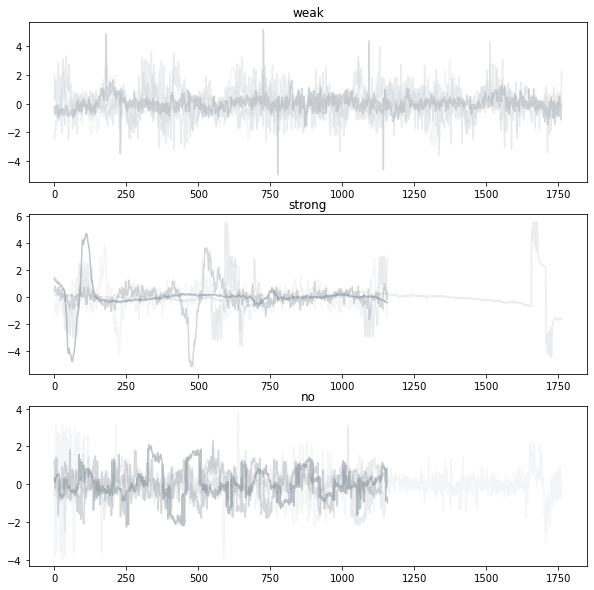

In [124]:
colors = ["#EAECEE", "#D5D8DC", "#D6DBDF", "#ABB2B9", "#808B96", "#2C3E50", "#273746", "#212F3D", "#1C2833", "#17202A"]

fig, axis = plt.subplots(3,1, figsize=(10,10))
for i in range(len(data_weak_detrend_mean)-1):
    axis[0].plot(data_weak_detrend_mean[i], color=colors[i], alpha=0.5)
axis[0].set_title("weak")
#axis[0].set_ylim(-2.5,2.5)
    #axis[0].plot(data_weak_detrend_mean[4], color='grey', alpha=0.3);
for i in range(len(data_strong_detrend_mean)): 
    axis[1].plot(data_strong_detrend_mean[i], color=colors[i], alpha=0.5)
axis[1].set_title("strong")
#axis[1].set_ylim(-2.5,2.5)
for i in range(len(data_no_detrend_mean)): 
    axis[2].plot(data_no_detrend_mean[i], color=colors[i], alpha=0.5)
axis[2].set_title("no")
#axis[2].set_ylim(-2.5,2.5)

## Weak Signal

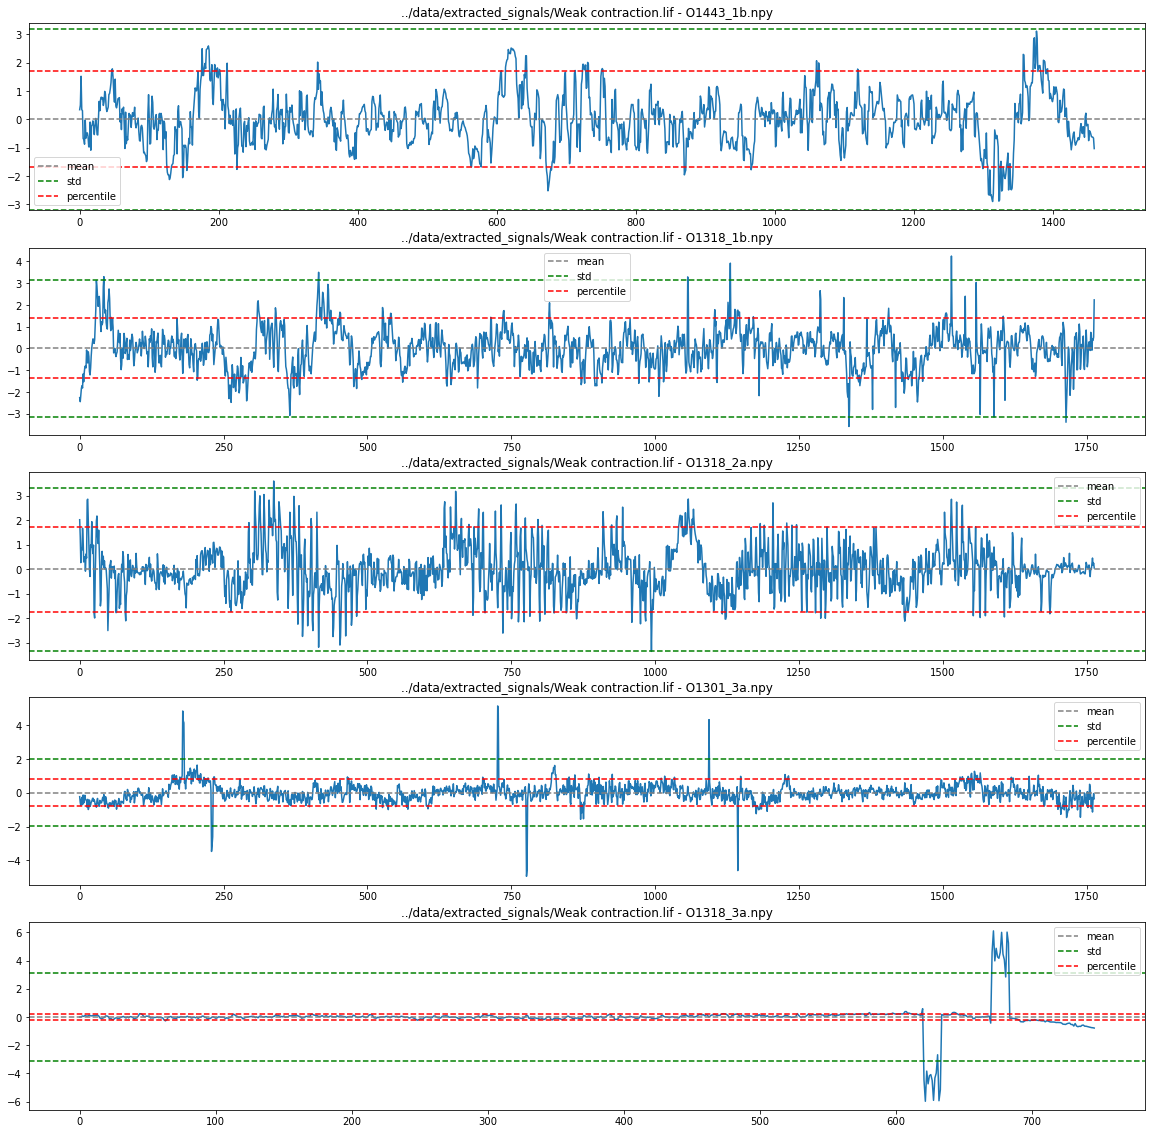

In [125]:
factor = 3.5
n = len(data_weak_detrend_mean)
fig, axis = plt.subplots(n, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    x = np.linspace(0, data_weak_detrend_mean[i].shape[0], data_weak_detrend_mean[i].shape[0])
    axis[i].plot(x, data_weak_detrend_mean[i])
    mean = statistics_weak_mean[i]['detrend_mean']['mean']
    std = statistics_weak_mean[i]['detrend_mean']['std']
    per = statistics_weak_mean[i]['detrend_mean']['per']
    axis[i].axhline(y=mean, color='grey', linestyle='--', label='mean')
    axis[i].axhline(y=factor*std, color='g', linestyle='--', label='std')
    axis[i].axhline(y=per, color='r', linestyle='--', label='percentile')
    axis[i].axhline(y=-factor*std, color='g', linestyle='--')
    axis[i].axhline(y=-per, color='r', linestyle='--')
    axis[i].set_title(file_name[idx_weak[i]])
    axis[i].legend()

## Strong Signal

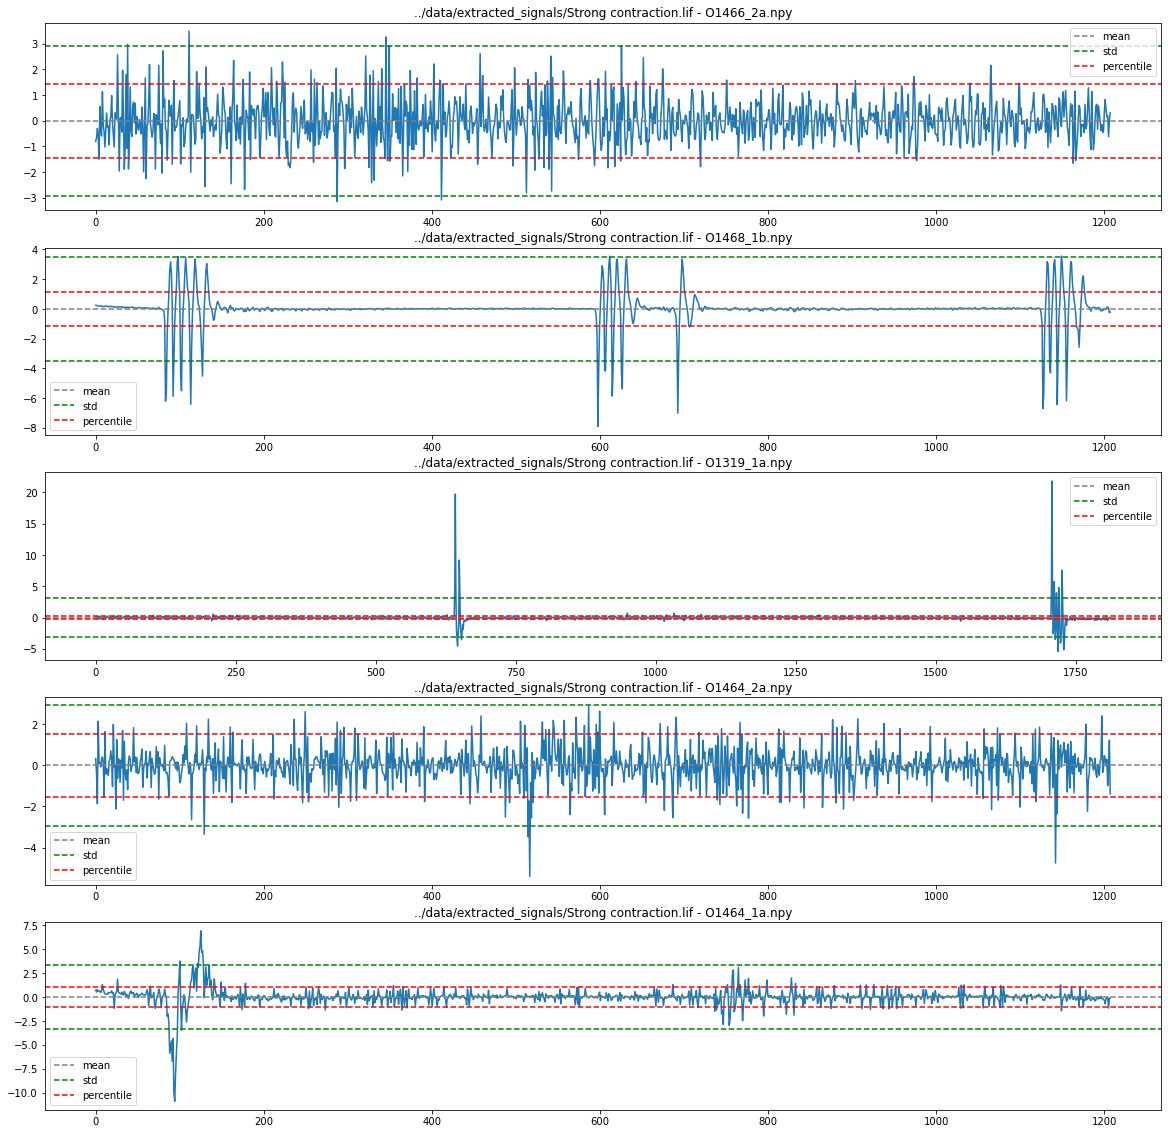

In [114]:
factor = 3.5
n = len(data_strong_detrend_mean)
fig, axis = plt.subplots(n, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    x = np.linspace(0, data_strong_detrend_mean[i].shape[0], data_strong_detrend_mean[i].shape[0])
    axis[i].plot(x, data_strong_detrend_mean[i])
    mean = statistics_strong_mean[i]['detrend_mean']['mean']
    std = statistics_strong_mean[i]['detrend_mean']['std']
    per = statistics_strong_mean[i]['detrend_mean']['per']
    axis[i].axhline(y=mean, color='grey', linestyle='--', label='mean')
    axis[i].axhline(y=factor*std, color='g', linestyle='--', label='std')
    axis[i].axhline(y=per, color='r', linestyle='--', label='percentile')
    axis[i].axhline(y=-factor*std, color='g', linestyle='--')
    axis[i].axhline(y=-per, color='r', linestyle='--')
    axis[i].set_title(file_name[idx_strong[i]])
    axis[i].legend()

## No Signal

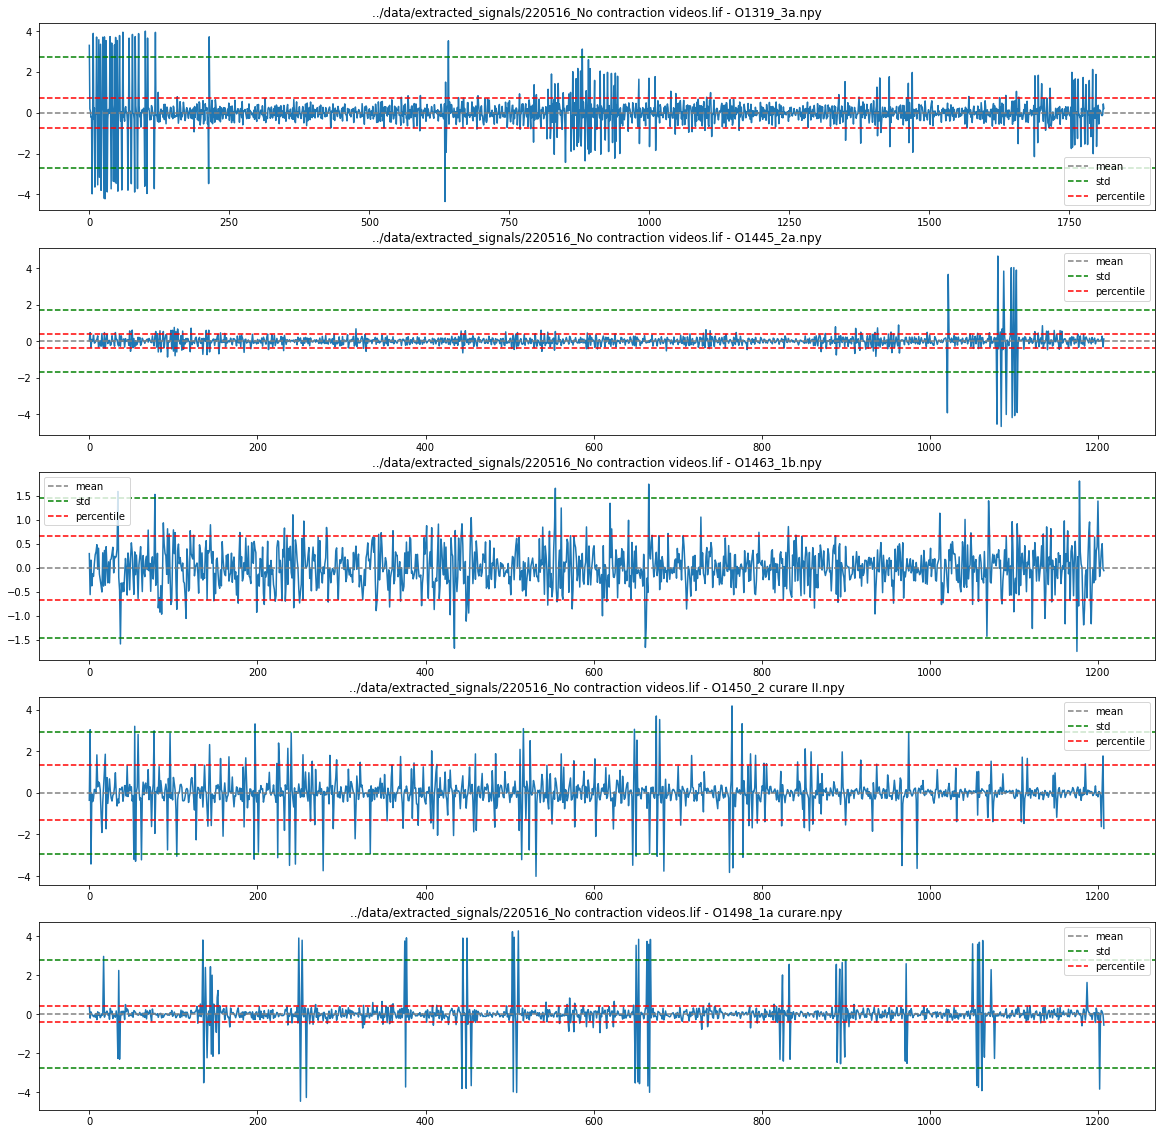

In [115]:
factor = 3.5
n = len(data_no_detrend_mean)
fig, axis = plt.subplots(n, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    x = np.linspace(0, data_no_detrend_mean[i].shape[0], data_no_detrend_mean[i].shape[0])
    axis[i].plot(x, data_no_detrend_mean[i])
    mean = statistics_no_mean[i]['detrend_mean']['mean']
    std = statistics_no_mean[i]['detrend_mean']['std']
    per = statistics_no_mean[i]['detrend_mean']['per']
    axis[i].axhline(y=mean, color='grey', linestyle='--', label='mean')
    axis[i].axhline(y=factor*std, color='g', linestyle='--', label='std')
    axis[i].axhline(y=per, color='r', linestyle='--', label='percentile')
    axis[i].axhline(y=-factor*std, color='g', linestyle='--')
    axis[i].axhline(y=-per, color='r', linestyle='--')
    axis[i].set_title(file_name[idx_no[i]])
    axis[i].legend()

# FFT

## Weak Signal

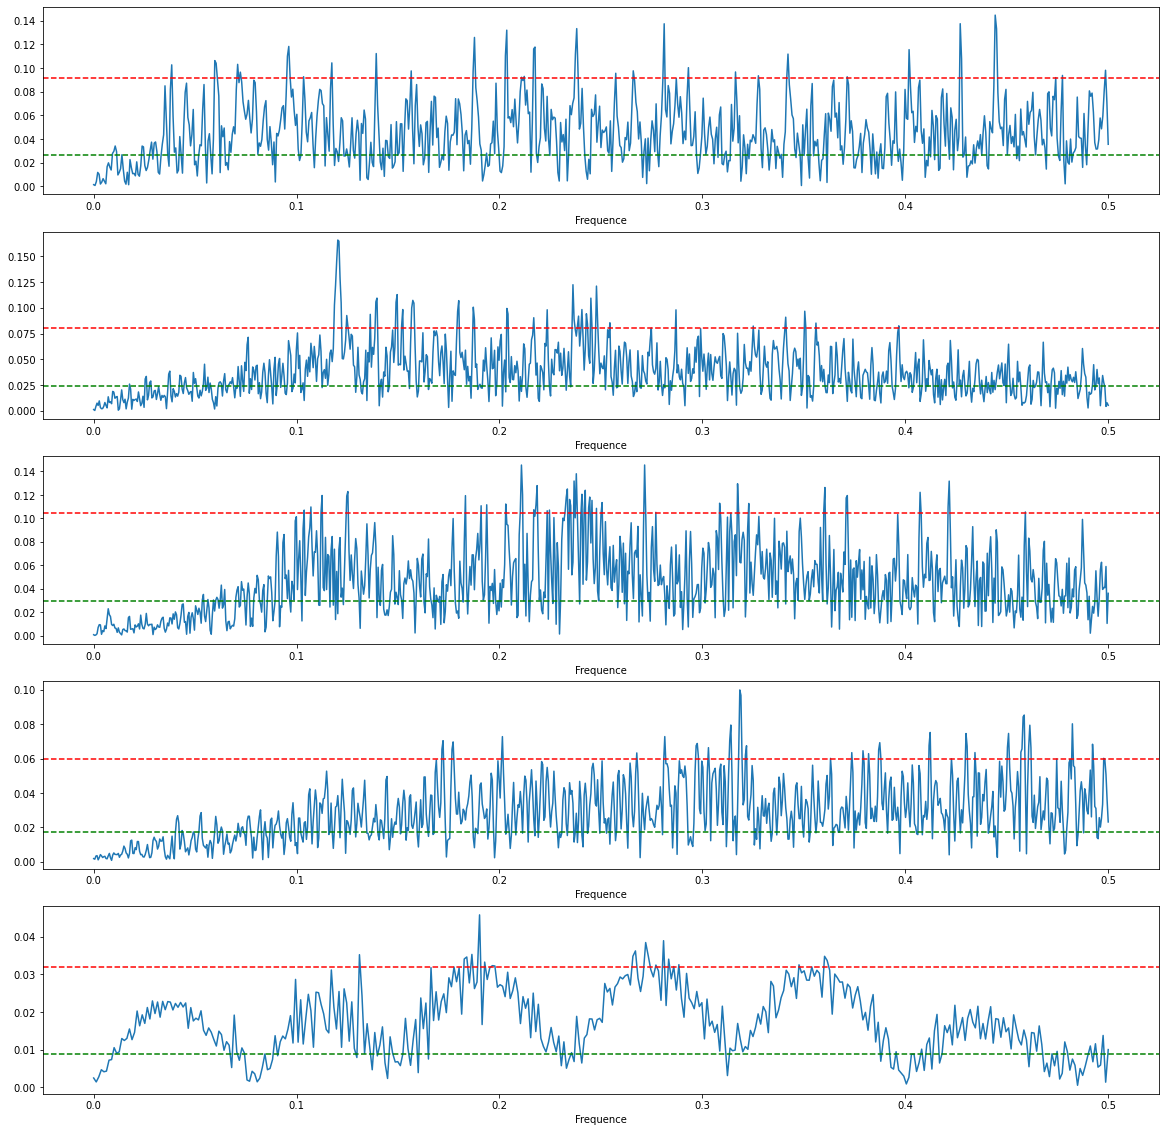

In [116]:
# fft
fig, axis = plt.subplots(5, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    N = int(data_weak_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_weak_mean[i][:N])/N
    ax.plot(X_weak_mean[i], ts)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[i].axhline(y=mean, color='grey', linestyle='--')
    axis[i].axhline(y=std, color='g', linestyle='--')
    axis[i].axhline(y=per, color='r', linestyle='--')
    #axis[i].set_ylim(0,0.2)

## Strong Signal

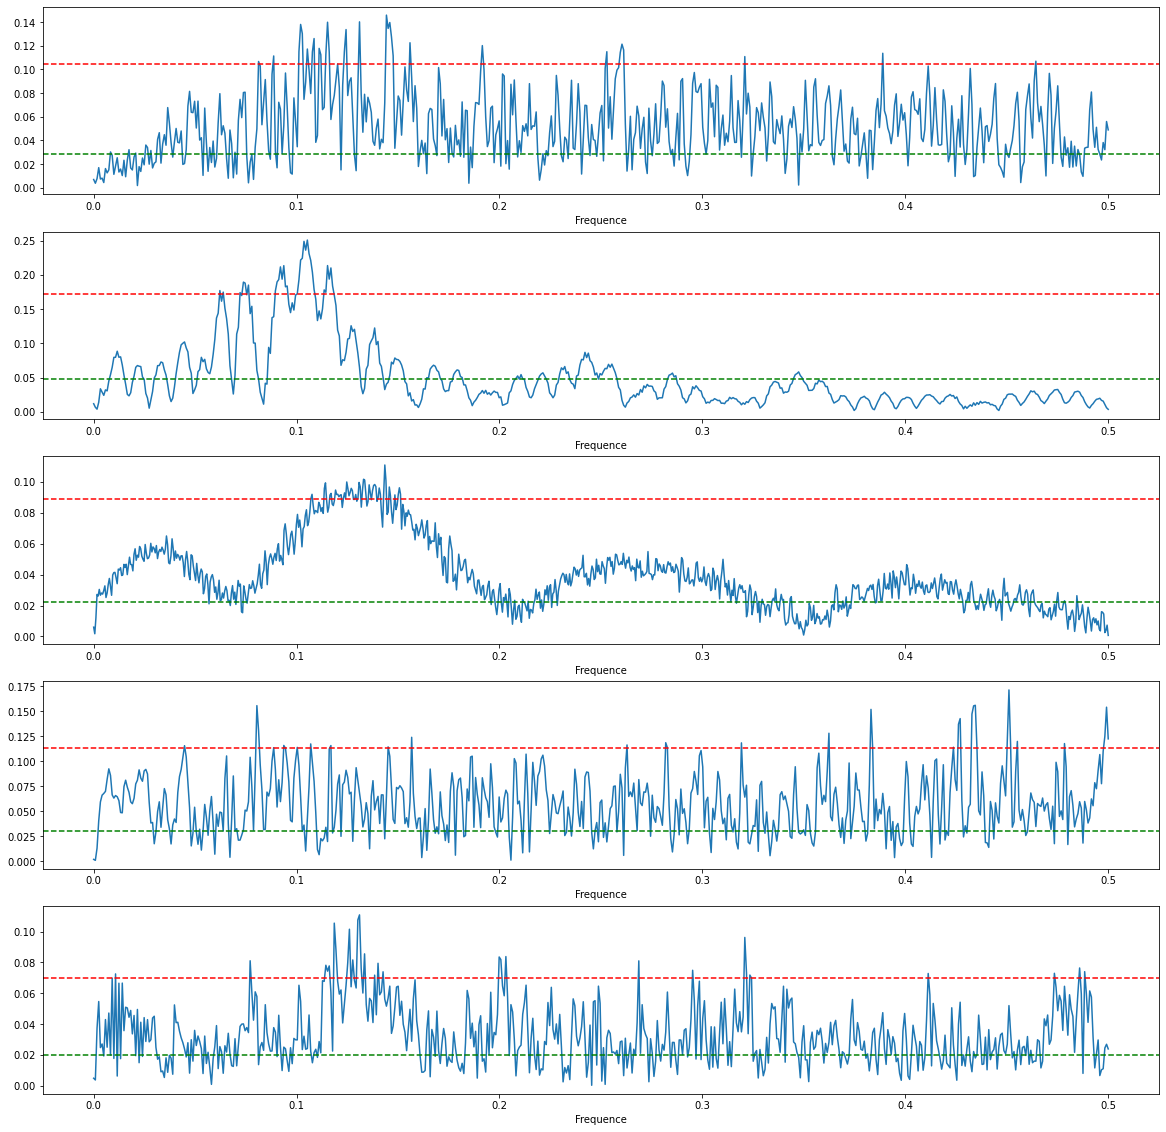

In [117]:
# fft
fig, axis = plt.subplots(5, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    N = int(data_strong_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_strong_mean[i][:N])/N
    ax.plot(X_strong_mean[i], ts)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[i].axhline(y=mean, color='grey', linestyle='--')
    axis[i].axhline(y=std, color='g', linestyle='--')
    axis[i].axhline(y=per, color='r', linestyle='--')
    #axis[i].set_ylim(0,0.4)

## No Signal

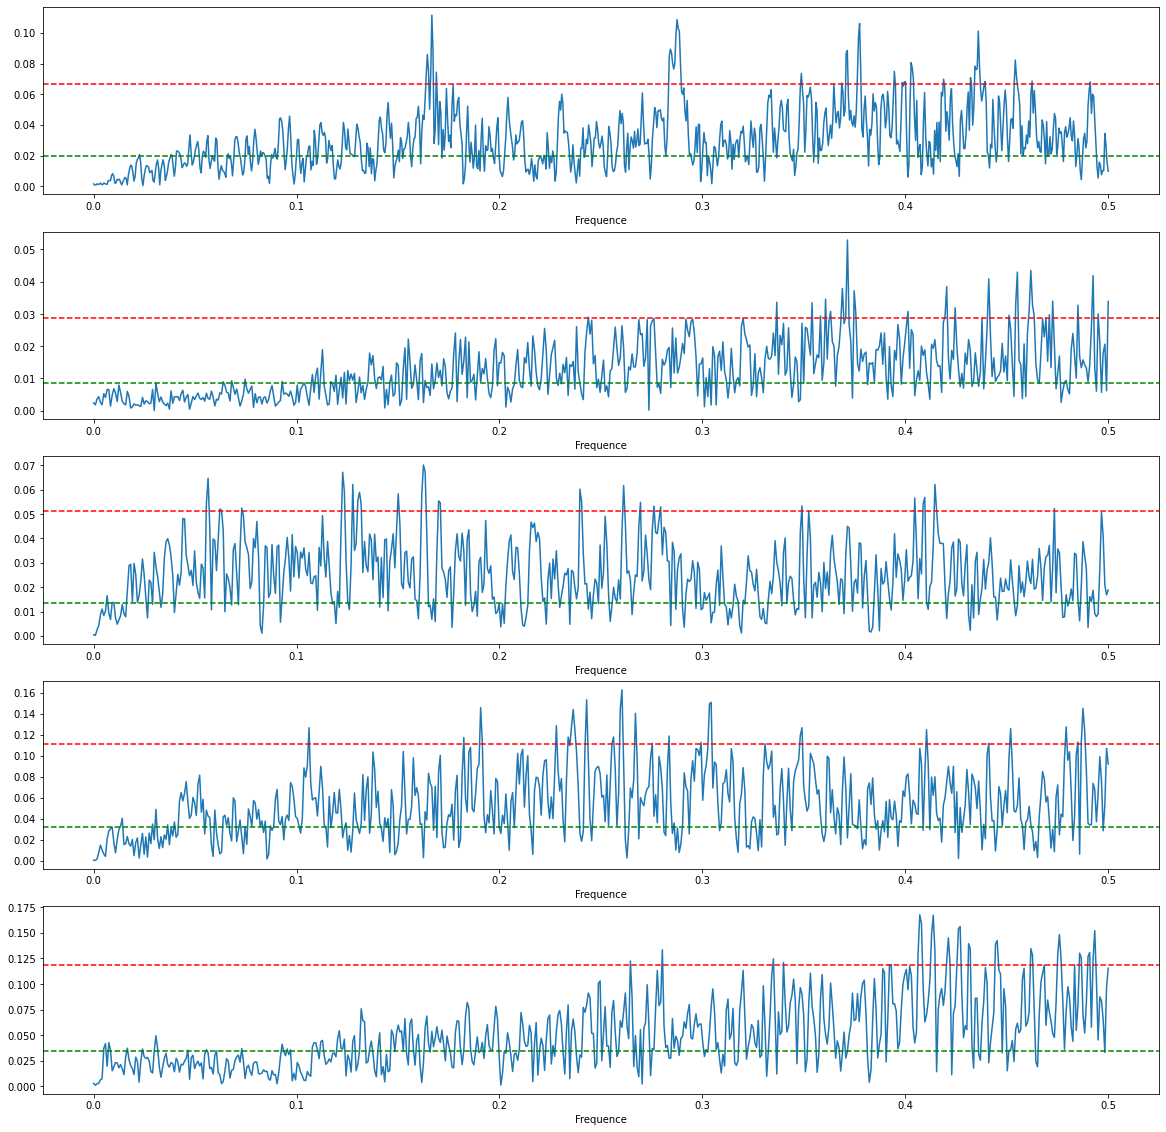

In [118]:
# fft
fig, axis = plt.subplots(5, 1, figsize=(20,20))
for i, ax in enumerate(axis):
    N = int(data_no_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_no_mean[i][:N])/N
    ax.plot(X_no_mean[i], ts)
    #plt.xticks([12, 24, 33, 84, 168])
    ax.set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[i].axhline(y=mean, color='grey', linestyle='--')
    axis[i].axhline(y=std, color='g', linestyle='--')
    axis[i].axhline(y=per, color='r', linestyle='--')
    #axis[i].set_ylim(0,0.08)

## Together

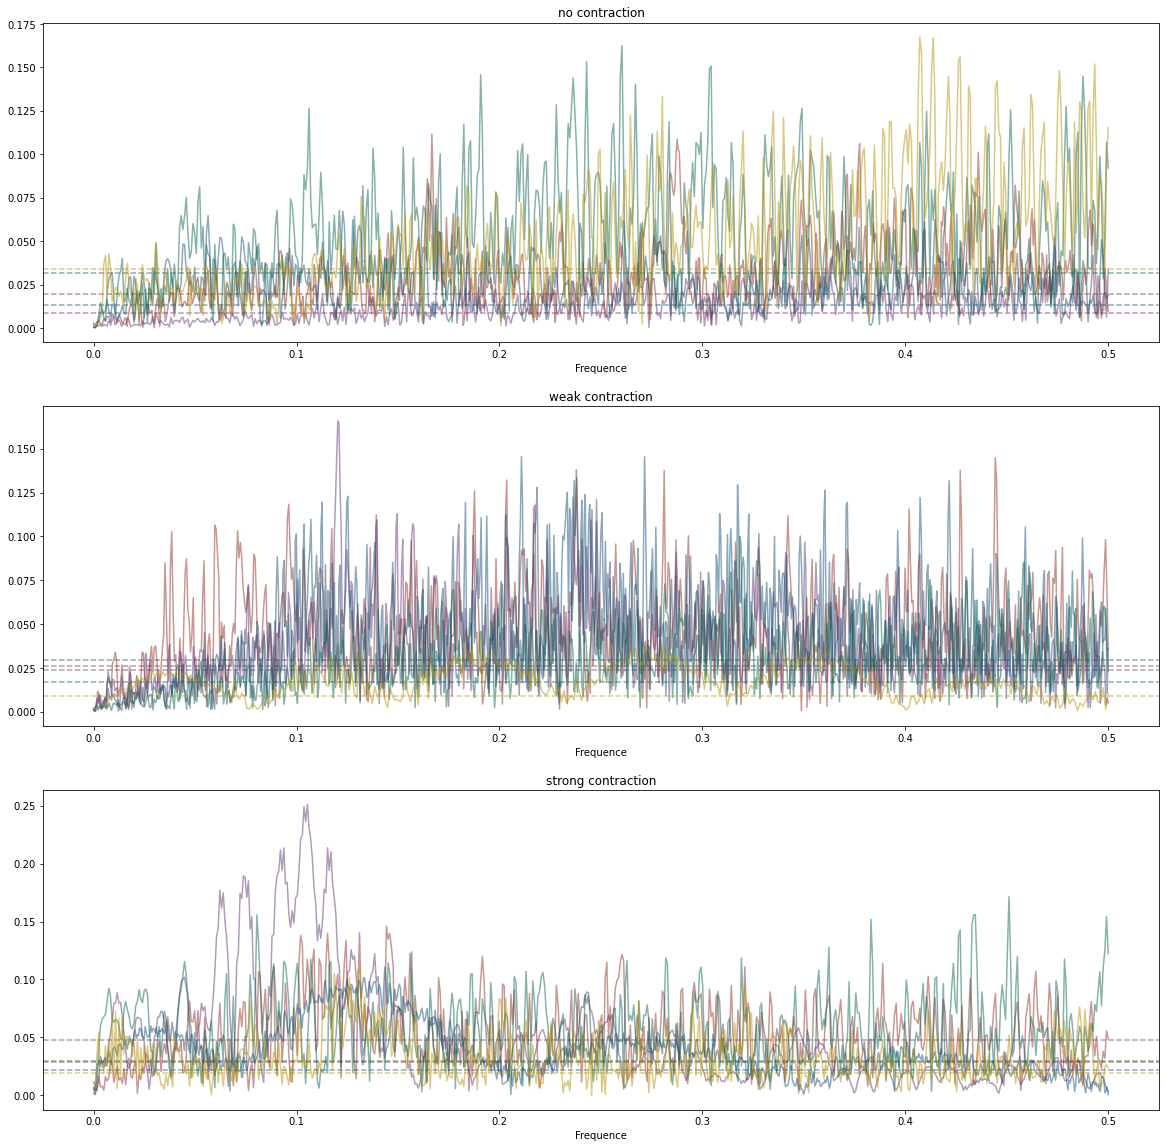

In [119]:
### All Together
factor = 1
colors = ['#943126', '#633974', '#1A5276', '#0E6655', '#B7950B']
fig, axis = plt.subplots(3, 1, figsize=(20,20))

for i in range(len(data_no_detrend_mean)):
    N = int(data_no_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_no_mean[i][:N])/N
    axis[0].plot(X_no_mean[i], ts, color=colors[i], alpha=0.5)
    axis[0].set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[0].axhline(y=mean, color='grey', linestyle='--')
    axis[0].axhline(y=factor*std, color=colors[i], linestyle='--', alpha=0.5)
    #axis[0].axhline(y=per, color=colors[i], linestyle='--')
    axis[0].set_title("no contraction")
    #axis[0].set_ylim(0,0.02)

for i in range(len(data_weak_detrend_mean)):
    N = int(data_weak_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_weak_mean[i][:N])/N
    axis[1].plot(X_weak_mean[i], ts, color=colors[i], alpha=0.5)
    axis[1].set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[1].axhline(y=mean, color='grey', linestyle='--')
    axis[1].axhline(y=factor*std, color=colors[i], linestyle='--', alpha=0.5)
    #axis[1].axhline(y=per, color=colors[i], linestyle='--')
    axis[1].set_title("weak contraction")
    #axis[1].set_ylim(0,0.02)
    
for i in range(len(data_strong_detrend_mean)):
    N = int(data_strong_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_strong_mean[i][:N])/N
    axis[2].plot(X_strong_mean[i], ts, color=colors[i], alpha=0.5)
    axis[2].set_xlabel('Frequence')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[2].axhline(y=mean, color='grey', linestyle='--')
    axis[2].axhline(y=factor*std, color=colors[i], linestyle='--', alpha=0.5)
    #axis[2].axhline(y=per, color=colors[i], linestyle='--')
    axis[2].set_title("strong contraction")
    #axis[2].set_ylim(0,0.02)

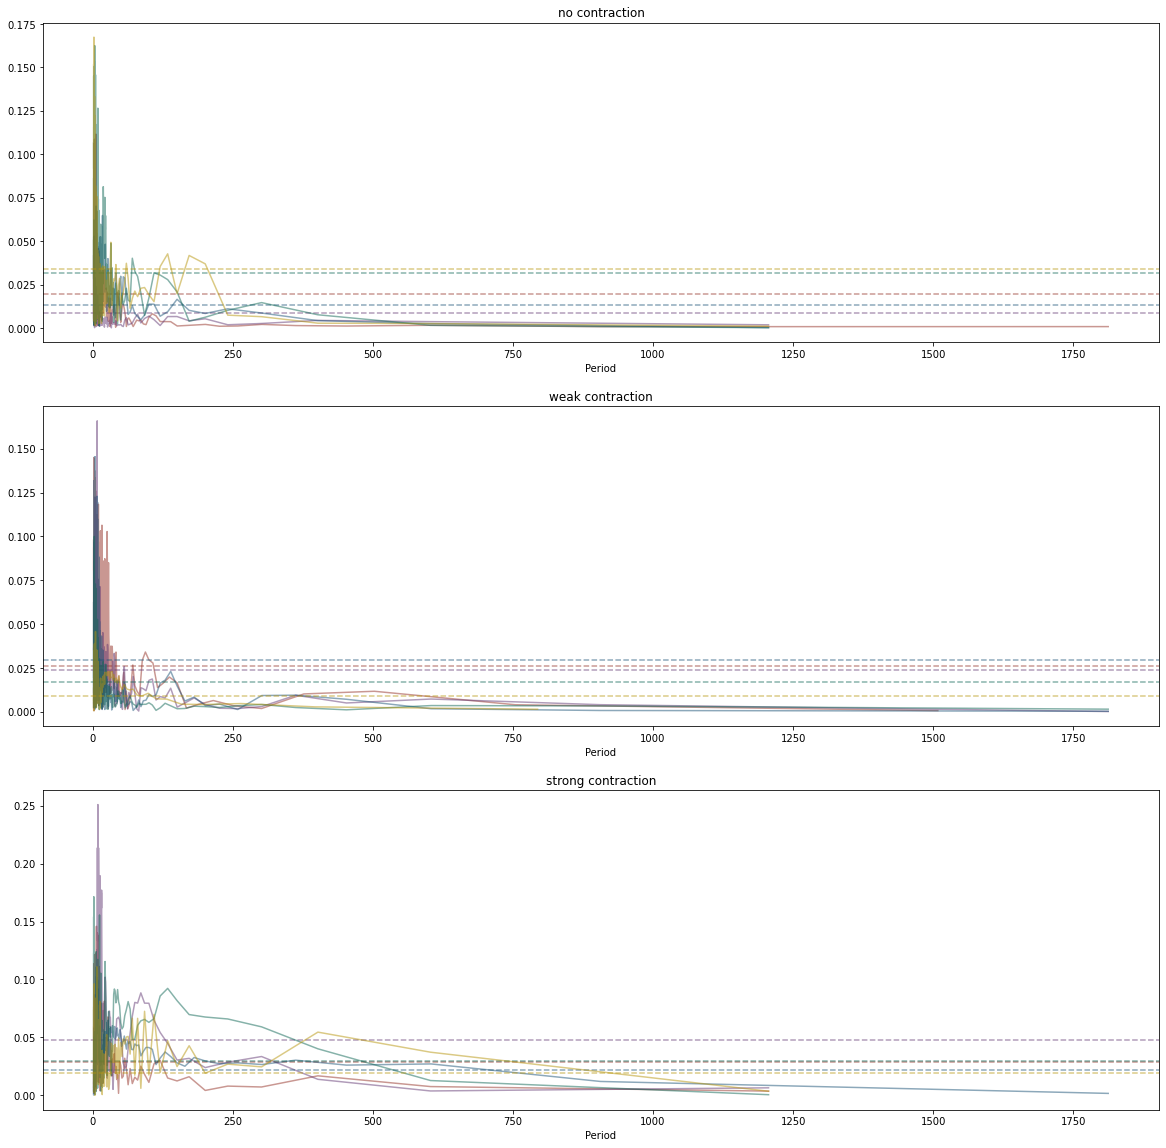

In [120]:
### All Together
factor = 1
colors = ['#943126', '#633974', '#1A5276', '#0E6655', '#B7950B']
fig, axis = plt.subplots(3, 1, figsize=(20,20))

for i in range(len(data_no_detrend_mean)):
    N = int(data_no_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_no_mean[i][:N])/N
    axis[0].plot(Xp_no_mean[i], ts, color=colors[i], alpha=0.5)
    #plt.xticks([12, 24, 33, 84, 168])
    axis[0].set_xlabel('Period')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[0].axhline(y=mean, color='grey', linestyle='--')
    axis[0].axhline(y=factor*std, color=colors[i], linestyle='--', alpha=0.5)
    #axis[0].axhline(y=per, color=colors[i], linestyle='--')
    axis[0].set_title("no contraction")

for i in range(len(data_weak_detrend_mean)):
    N = int(data_weak_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_weak_mean[i][:N])/N
    axis[1].plot(Xp_weak_mean[i], ts, color=colors[i], alpha=0.5)
    #plt.xticks([12, 24, 33, 84, 168])
    axis[1].set_xlabel('Period')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[1].axhline(y=mean, color='grey', linestyle='--')
    axis[1].axhline(y=factor*std, color=colors[i], linestyle='--', alpha=0.5)
    #axis[1].axhline(y=per, color=colors[i], linestyle='--')
    axis[1].set_title("weak contraction")
    
for i in range(len(data_strong_detrend_mean)):
    N = int(data_strong_detrend_mean[i].shape[0]/2) + 1
    ts = 2.0*np.abs(y_hann_strong_mean[i][:N])/N
    axis[2].plot(Xp_strong_mean[i], ts, color=colors[i], alpha=0.5)
    #plt.xticks([12, 24, 33, 84, 168])
    axis[2].set_xlabel('Period')
    mean = np.mean(ts)
    std = np.std(ts)
    per = np.percentile(ts, 95)
    #axis[2].axhline(y=mean, color='grey', linestyle='--')
    axis[2].axhline(y=factor*std, color=colors[i], linestyle='--', alpha=0.5)
    #axis[2].axhline(y=per, color=colors[i], linestyle='--')
    axis[2].set_title("strong contraction")